# 02d — Road Network Access Analysis

Measures how much each digitizer's additions to the OSM road network reduce the **access gap**: the distance a person at an arbitrary location must travel before reaching any road.

Three networks are compared at settlement-wide scale:
- `G_osm` — OSM highways only (baseline)
- `G_<participant>+osm` — each participant's digitized roads merged with OSM

**Metric:** for a dense regular grid of points covering the settlement, compute the Euclidean distance from each point to its nearest graph node.  Differences in that distribution show where and how much digitization improves access.

> Note: this uses straight-line distance to the nearest network node as a proxy for access.  It does not model off-road walking speed or path-finding — it answers "how far am I from *any* road?"

In [1]:
# ── Parameters — edit this cell only ───────────────────────────────────────

SETTLEMENT = "nakivale"

PARTICIPANTS = [
    {"lastname": "casey", "dig_file": "Sample_Digitization_Nakivale_Casey.geojson"},
    {"lastname": "tanna", "dig_file": "Sample_Digitization_Nakivale_Tanna.geojson"},
]

PROJECTED_CRS   = "EPSG:32636"   # UTM Zone 36N
GRID_SPACING_M  = 50             # spacing between sample points (metres)
ROUTING_SNAP_M  = 20             # max distance to snap dig endpoint to OSM segment
ACCESS_THRESHOLDS_M = [100, 250, 500]  # coverage radii to report


In [2]:
import warnings
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import networkx as nx
import numpy as np
import pandas as pd
import yaml
from scipy.spatial import cKDTree
from shapely.geometry import Point, LineString, MultiPoint, box as shp_box
from shapely.ops import unary_union

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.2f}".format)


In [3]:
def find_project_root(start=None):
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "configs" / "paths.yaml").exists():
            return candidate
    raise FileNotFoundError("configs/paths.yaml not found")

project_root = find_project_root()
with open(project_root / "configs" / "paths.yaml") as f:
    _paths = yaml.safe_load(f)

processed_dir = project_root / _paths["data"]["processed"]
assign_dir    = processed_dir / "assignments"
dig_dir       = processed_dir / "sample_digitization"

_PALETTE = ["#2166ac", "#d6604d", "#1a9641", "#762a83"]
LABELS   = [p["lastname"].capitalize() for p in PARTICIPANTS]
COLORS   = {label: _PALETTE[i] for i, label in enumerate(LABELS)}
COLORS["OSM only"] = "#888888"

# Output directory: outputs/{settlement}/{label1}_vs_{label2}/
_dig_slug = "_vs_".join(l.lower() for l in LABELS)
out_dir = project_root / "outputs" / SETTLEMENT / _dig_slug
out_dir.mkdir(parents=True, exist_ok=True)

def savefig(name, fig=None, **kwargs):
    path = out_dir / f"{name}.png"
    (fig or plt).savefig(path, dpi=150, bbox_inches="tight", **kwargs)
    print(f"  Saved → {path.relative_to(project_root)}")

def savecsv(df, name):
    path = out_dir / f"{name}.csv"
    df.to_csv(path, index=True)
    print(f"  Saved → {path.relative_to(project_root)}")

print(f"Settlement : {SETTLEMENT}")
print(f"Participants: {LABELS}")
print(f"Output dir : {out_dir}")


Settlement : nakivale
Participants: ['Casey', 'Tanna']
Output dir : C:\Users\Zachary\phd_classes\uganda\outputs\nakivale\casey_vs_tanna


## 1  Load data

In [4]:
# Settlement boundary
boundary = gpd.read_file(
    processed_dir / f"UNHCR_poc_boundaries-Uganda_{SETTLEMENT}_utm36N.geojson"
).to_crs(PROJECTED_CRS)
settlement_union = boundary.geometry.unary_union
print(f"Settlement boundary loaded  area={settlement_union.area/1e6:.1f} km²")

# OSM roads
_osm_candidates = [
    processed_dir / f"{SETTLEMENT}_osm_highways_utm36N.geojson",
    processed_dir / f"{SETTLEMENT}_osm_roads_and_footpaths_utm36N.geojson",
    processed_dir / f"{SETTLEMENT}_osm_roads_utm36N.geojson",
]
osm_path = next((p for p in _osm_candidates if p.exists()), None)
assert osm_path, f"No OSM file found for {SETTLEMENT}"
osm_gdf = (
    gpd.read_file(osm_path).to_crs(PROJECTED_CRS)
    .pipe(lambda g: g[g.geometry.type.isin(["LineString", "MultiLineString"])])
    .explode(index_parts=False).reset_index(drop=True)
)
print(f"OSM roads loaded: {len(osm_gdf)} segments  ({osm_path.name})")

# Digitized roads — full assignment for each participant
lines_gdfs = {}
for p in PARTICIPANTS:
    label    = p["lastname"].capitalize()
    dig_path = dig_dir / p["dig_file"]
    raw = gpd.read_file(dig_path).to_crs(PROJECTED_CRS)
    lines_gdfs[label] = raw.explode(index_parts=False).reset_index(drop=True)
    print(f"  {label}: {len(lines_gdfs[label])} digitized segments  ({dig_path.name})")


Settlement boundary loaded  area=458.1 km²
OSM roads loaded: 2105 segments  (nakivale_osm_highways_utm36N.geojson)
  Casey: 813 digitized segments  (Sample_Digitization_Nakivale_Casey.geojson)
  Tanna: 427 digitized segments  (Sample_Digitization_Nakivale_Tanna.geojson)


## 2  Graph-building helpers

In [6]:
def _extract_lines(geom):
    if geom is None or geom.is_empty: return []
    t = geom.geom_type
    if t in ("LineString", "LinearRing"): return [geom]
    if t == "MultiLineString": return list(geom.geoms)
    if hasattr(geom, "geoms"):
        out = []
        for g in geom.geoms: out.extend(_extract_lines(g))
        return out
    return []


def _gdf_to_graph(lines_gdf, clip_geom=None):
    """Build a NetworkX graph from a GeoDataFrame of lines, optionally clipped."""
    if clip_geom is not None:
        sub = lines_gdf[lines_gdf.intersects(clip_geom)].copy()
        if sub.empty: return nx.Graph()
        sub["geometry"] = sub.geometry.intersection(clip_geom)
        sub = sub[~sub.geometry.is_empty]
    else:
        sub = lines_gdf
    if sub.empty: return nx.Graph()
    G = nx.Graph()
    for geom in sub.geometry:
        for line in _extract_lines(geom):
            coords = list(line.coords)
            for i in range(len(coords) - 1):
                u = (round(coords[i][0],   1), round(coords[i][1],   1))
                v = (round(coords[i+1][0], 1), round(coords[i+1][1], 1))
                d = Point(coords[i]).distance(Point(coords[i+1]))
                if G.has_edge(u, v):
                    G[u][v]["weight"] = min(G[u][v]["weight"], d)
                else:
                    G.add_edge(u, v, weight=d)
    return G


def _build_segment_index(G):
    """Dense 2m sample along each edge → cKDTree for nearest-segment queries."""
    segments, sample_pts, SAMPLE_M = [], [], 2.0
    for u, v in G.edges():
        seg   = LineString([u, v])
        n_pts = max(2, int(seg.length / SAMPLE_M) + 1)
        for t in np.linspace(0, 1, n_pts):
            pt = seg.interpolate(t, normalized=True)
            sample_pts.append((pt.x, pt.y, len(segments)))
        segments.append((u, v, seg))
    if not sample_pts:
        return segments, None, None
    pts_arr = np.array([(x, y) for x, y, _ in sample_pts])
    seg_idx = np.array([s for _, _, s in sample_pts], dtype=int)
    return segments, cKDTree(pts_arr), seg_idx


def _snap_and_merge(G_dig, G_osm, snap_m):
    """
    Project digitized endpoints onto the nearest OSM segment within snap_m,
    splitting the OSM edge at the projection point (T-junction).
    Returns the merged graph.
    """
    if G_osm.number_of_nodes() == 0:
        return G_dig
    if G_dig.number_of_nodes() == 0:
        return G_osm

    segments, tree, seg_idx = _build_segment_index(G_osm)
    if tree is None:
        return nx.compose(G_dig, G_osm)

    dig_nodes = list(G_dig.nodes)
    dist, nearest = tree.query(np.array(dig_nodes), workers=-1)

    rename, split_edges = {}, {}
    for node, d, si in zip(dig_nodes, dist, seg_idx[nearest]):
        if d > snap_m: continue
        u, v, seg = segments[si]
        proj_pt = seg.interpolate(seg.project(Point(node)))
        snapped = (round(proj_pt.x, 1), round(proj_pt.y, 1))
        rename[node] = snapped
        key = (u, v) if G_osm.has_edge(u, v) else (v, u)
        split_edges.setdefault(key, []).append((seg.project(Point(node)), snapped))

    G_merged = nx.Graph()
    for u, v, data in G_osm.edges(data=True):
        key = (u, v) if (u, v) in split_edges else ((v, u) if (v, u) in split_edges else None)
        if key is None:
            G_merged.add_edge(u, v, weight=data.get("weight", 0))
        else:
            seg    = LineString([u, v])
            splits = sorted(split_edges[key], key=lambda x: x[0])
            chain  = [u] + [c for _, c in splits] + [v]
            pts    = [Point(u)] + [Point(c) for _, c in splits] + [Point(v)]
            for i in range(len(chain) - 1):
                a, b = chain[i], chain[i + 1]
                sub_len = pts[i].distance(pts[i + 1])
                if G_merged.has_edge(a, b):
                    G_merged[a][b]["weight"] = min(G_merged[a][b]["weight"], sub_len)
                else:
                    G_merged.add_edge(a, b, weight=sub_len)

    for u, v, data in G_dig.edges(data=True):
        u2, v2 = rename.get(u, u), rename.get(v, v)
        if u2 == v2: continue
        w = data.get("weight", 0)
        if G_merged.has_edge(u2, v2):
            G_merged[u2][v2]["weight"] = min(G_merged[u2][v2]["weight"], w)
        else:
            G_merged.add_edge(u2, v2, weight=w)

    return G_merged


## 3  Build settlement-wide networks

Each network covers the **full digitized assignment area** for the participant — not just QA overlap cells.

In [7]:
print("Building OSM graph...")
G_osm = _gdf_to_graph(osm_gdf)
print(f"  G_osm: {G_osm.number_of_nodes():,} nodes, {G_osm.number_of_edges():,} edges")

graphs = {"OSM only": G_osm}

for label in LABELS:
    print(f"Building {label} + OSM graph...")
    G_dig    = _gdf_to_graph(lines_gdfs[label])
    G_merged = _snap_and_merge(G_dig, G_osm, ROUTING_SNAP_M)
    graphs[label] = G_merged
    n_new = G_merged.number_of_nodes() - G_osm.number_of_nodes()
    e_new = G_merged.number_of_edges() - G_osm.number_of_edges()
    print(f"  {label}+OSM: {G_merged.number_of_nodes():,} nodes (+{n_new:,}), "
          f"{G_merged.number_of_edges():,} edges (+{e_new:,})")


Building OSM graph...
  G_osm: 46,636 nodes, 47,426 edges
Building Casey + OSM graph...
  Casey+OSM: 55,893 nodes (+9,257), 56,768 edges (+9,342)
Building Tanna + OSM graph...
  Tanna+OSM: 51,724 nodes (+5,088), 52,632 edges (+5,206)


## 4  Generate sample point grid

A regular grid of points at `GRID_SPACING_M` covering the settlement boundary.  These represent arbitrary population locations — people who may be anywhere in the settlement, not just on a road.

In [8]:
minx, miny, maxx, maxy = settlement_union.bounds
xs = np.arange(minx, maxx, GRID_SPACING_M)
ys = np.arange(miny, maxy, GRID_SPACING_M)
xx, yy = np.meshgrid(xs, ys)
all_pts = np.column_stack([xx.ravel(), yy.ravel()])

# Keep only points inside the settlement boundary
from shapely.vectorized import contains
inside_mask = contains(settlement_union, all_pts[:, 0], all_pts[:, 1])
sample_pts  = all_pts[inside_mask]

print(f"Sample points: {len(sample_pts):,}  "
      f"(grid {GRID_SPACING_M}m, {len(xs)}x{len(ys)} = {len(all_pts):,} total, "
      f"{inside_mask.sum():,} inside settlement)")


Sample points: 183,279  (grid 50m, 632x440 = 278,080 total, 183,279 inside settlement)


## 5  Compute nearest-node access distances

For each network, build a `cKDTree` over all graph nodes and query the nearest node for every sample point.  The query distance is the **access gap** — how far a person at that location must travel before reaching the network.

In [9]:
access = {}   # label -> np.array of distances (one per sample point)

for name, G in graphs.items():
    if G.number_of_nodes() == 0:
        access[name] = np.full(len(sample_pts), np.nan)
        continue
    nodes_arr = np.array(list(G.nodes))
    tree = cKDTree(nodes_arr)
    dist, _ = tree.query(sample_pts, workers=-1)
    access[name] = dist
    print(f"  {name:20s}  median={np.median(dist):.1f}m  "
          f"mean={np.mean(dist):.1f}m  max={np.max(dist):.1f}m")


  OSM only              median=170.5m  mean=313.1m  max=2575.8m
  Casey                 median=139.8m  mean=257.8m  max=2244.8m
  Tanna                 median=155.4m  mean=281.3m  max=2478.0m


## 6  Coverage at distance thresholds

Fraction of settlement area within `T` metres of any road node, for each network.

In [10]:
coverage_rows = []
for name, dist in access.items():
    row = {"network": name}
    row["median_m"]  = float(np.nanmedian(dist))
    row["mean_m"]    = float(np.nanmean(dist))
    row["p75_m"]     = float(np.nanpercentile(dist, 75))
    row["p90_m"]     = float(np.nanpercentile(dist, 90))
    for t in ACCESS_THRESHOLDS_M:
        row[f"pct_within_{t}m"] = float((dist <= t).mean() * 100)
    coverage_rows.append(row)

coverage_df = pd.DataFrame(coverage_rows).set_index("network")
display(coverage_df.round(1))
savecsv(coverage_df, "20_access_coverage_table")


,median_m,mean_m,p75_m,p90_m,pct_within_100m,pct_within_250m,pct_within_500m
network,,,,,,,
OSM only,170.50,313.10,373.60,758.80,34.20,62.20,82.70
Casey,139.80,257.80,315.20,626.90,39.70,68.20,86.40
Tanna,155.40,281.30,346.20,673.70,37.00,64.80,84.70


  Saved → outputs\nakivale\casey_vs_tanna\20_access_coverage_table.csv


## 7  Access distance distributions

  Saved → outputs\nakivale\casey_vs_tanna\20_access_distance_distributions.png


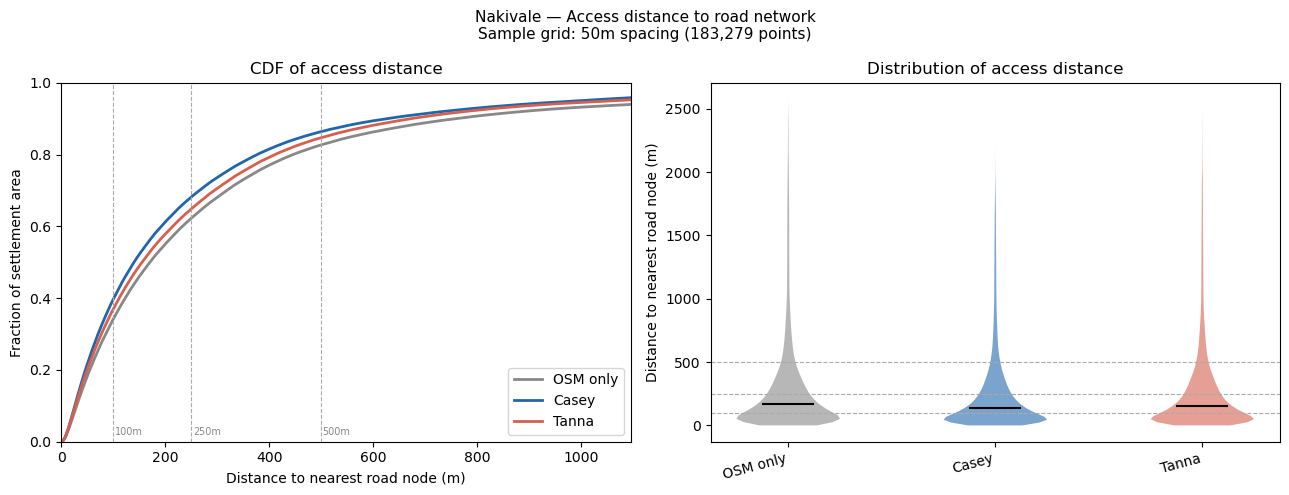

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: CDF
ax = axes[0]
x_max = np.nanpercentile(np.concatenate(list(access.values())), 95)
x_vals = np.linspace(0, x_max, 500)
for name, dist in access.items():
    color = COLORS.get(name, "#333333")
    cdf = [(dist <= x).mean() for x in x_vals]
    ax.plot(x_vals, cdf, label=name, color=color, linewidth=2)
for t in ACCESS_THRESHOLDS_M:
    ax.axvline(t, color="#aaaaaa", linestyle="--", linewidth=0.8)
    ax.text(t + 3, 0.02, f"{t}m", fontsize=7, color="#888888")
ax.set_xlabel("Distance to nearest road node (m)")
ax.set_ylabel("Fraction of settlement area")
ax.set_title("CDF of access distance")
ax.legend()
ax.set_xlim(0, x_max)
ax.set_ylim(0, 1)

# Right: violin / box
ax2 = axes[1]
names  = list(access.keys())
colors = [COLORS.get(n, "#333333") for n in names]
parts  = ax2.violinplot([access[n] for n in names], positions=range(len(names)),
                        showmedians=True, showextrema=False)
for pc, col in zip(parts["bodies"], colors):
    pc.set_facecolor(col); pc.set_alpha(0.6)
parts["cmedians"].set_color("black")
ax2.set_xticks(range(len(names)))
ax2.set_xticklabels(names, rotation=15, ha="right")
ax2.set_ylabel("Distance to nearest road node (m)")
ax2.set_title("Distribution of access distance")
for t in ACCESS_THRESHOLDS_M:
    ax2.axhline(t, color="#aaaaaa", linestyle="--", linewidth=0.8)

plt.suptitle(
    f"{SETTLEMENT.capitalize()} — Access distance to road network\n"
    f"Sample grid: {GRID_SPACING_M}m spacing ({len(sample_pts):,} points)",
    fontsize=11
)
plt.tight_layout()
savefig("20_access_distance_distributions")
plt.show()


## 8  Spatial map of access improvement

For each sample point, how much does each participant's network reduce the access distance vs OSM-only?  Positive values (warmer colours) = the digitized roads bring that location closer to a road.

In [ ]:
osm_dist = access["OSM only"]

n_participants = len(LABELS)
fig, axes = plt.subplots(1, n_participants + 1,
                         figsize=(6 * (n_participants + 1), 6),
                         squeeze=False)
axes = axes[0]

# col 0: OSM baseline access distance
ax0 = axes[0]
sc0 = ax0.scatter(sample_pts[:, 0], sample_pts[:, 1],
                  c=osm_dist, cmap="YlOrRd", s=1, vmin=0,
                  vmax=np.nanpercentile(osm_dist, 95))
boundary.plot(ax=ax0, facecolor="none", edgecolor="black", linewidth=1)
plt.colorbar(sc0, ax=ax0, label="Distance to nearest OSM node (m)")
ax0.set_title("OSM only — access distance", fontsize=10)
ax0.set_aspect("equal"); ax0.axis("off")

# cols 1+: improvement = osm_dist - participant_dist  (positive = improvement)
for i, label in enumerate(LABELS):
    ax = axes[i + 1]
    improvement = osm_dist - access[label]
    vabs = np.nanpercentile(np.abs(improvement), 95)
    sc = ax.scatter(sample_pts[:, 0], sample_pts[:, 1],
                    c=improvement, cmap="RdYlGn", s=1,
                    vmin=-vabs, vmax=vabs)
    boundary.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1)
    plt.colorbar(sc, ax=ax, label="Access improvement (m)")
    ax.set_title(f"{label} — reduction in access distance vs OSM", fontsize=10)
    ax.set_aspect("equal"); ax.axis("off")

plt.suptitle(
    f"{SETTLEMENT.capitalize()} — Where do digitized roads improve access?\n"
    f"Green = closer to a road with digitization  |  Red = further (should be rare)",
    fontsize=11
)
plt.tight_layout()
savefig("21_access_improvement_map")
plt.show()


## 9  Side-by-side access maps (all networks)

Same colour scale across all panels so spatial patterns are directly comparable.

In [ ]:
all_dist = np.concatenate(list(access.values()))
vmax_shared = np.nanpercentile(all_dist, 95)

n_nets = len(graphs)
fig, axes = plt.subplots(1, n_nets, figsize=(6 * n_nets, 6), squeeze=False)
axes = axes[0]

for ax, (name, dist) in zip(axes, access.items()):
    sc = ax.scatter(sample_pts[:, 0], sample_pts[:, 1],
                    c=dist, cmap="YlOrRd_r", s=1, vmin=0, vmax=vmax_shared)
    boundary.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1)
    median_m = np.nanmedian(dist)
    ax.set_title(f"{name}\nmedian access = {median_m:.0f} m", fontsize=9)
    ax.set_aspect("equal"); ax.axis("off")

plt.colorbar(sc, ax=axes[-1], label="Distance to nearest road node (m)")
plt.suptitle(
    f"{SETTLEMENT.capitalize()} — Access distance (shared colour scale)\n"
    f"Darker = closer to road  |  {GRID_SPACING_M}m sample grid",
    fontsize=11
)
plt.tight_layout()
savefig("22_access_maps_all_networks")
plt.show()


## 10  Per-grid-cell access summary

Aggregate the sample-point access distances by 1km grid cell.  Shows which specific cells benefit most from digitization.

In [ ]:
grid = gpd.read_file(processed_dir / f"{SETTLEMENT}_1km_grids.geojson").to_crs(PROJECTED_CRS)

# Tag each sample point with its grid cell OID
sample_gdf = gpd.GeoDataFrame(
    geometry=[Point(x, y) for x, y in sample_pts],
    crs=PROJECTED_CRS
)
joined = gpd.sjoin(sample_gdf, grid[["OID", "geometry"]], how="left", predicate="within")
joined = joined.dropna(subset=["OID"]).copy()
joined["OID"] = joined["OID"].astype(int)

for name, dist in access.items():
    joined[f"dist_{name.replace(' ', '_')}"] = dist[joined.index]

cell_summary_rows = []
for oid, grp in joined.groupby("OID"):
    row = {"OID": oid, "n_pts": len(grp)}
    for name in access:
        col = f"dist_{name.replace(' ', '_')}"
        row[f"median_{name}"] = float(grp[col].median())
    # improvement = how much each participant reduces access vs OSM
    for label in LABELS:
        row[f"improvement_{label}_m"] = (
            row["median_OSM only"] - row[f"median_{label}"]
        )
    cell_summary_rows.append(row)

cell_summary = pd.DataFrame(cell_summary_rows).set_index("OID")
print(f"Cells summarised: {len(cell_summary)}")
display(cell_summary.sort_values(f"improvement_{LABELS[0]}_m", ascending=False).head(15).round(1))
savecsv(cell_summary, "23_per_cell_access_summary")


## 11  Per-cell improvement choropleth

In [ ]:
cell_geo = grid.merge(cell_summary.reset_index(), on="OID", how="left")

fig, axes = plt.subplots(1, len(LABELS), figsize=(8 * len(LABELS), 7), squeeze=False)
axes = axes[0]

for ax, label in zip(axes, LABELS):
    col = f"improvement_{label}_m"
    vabs = cell_geo[col].abs().quantile(0.95)
    cell_geo.plot(
        column=col, ax=ax, cmap="RdYlGn",
        vmin=-vabs, vmax=vabs,
        edgecolor="#cccccc", linewidth=0.3, legend=True,
        legend_kwds={"label": "Median access improvement (m)", "shrink": 0.6}
    )
    boundary.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1)
    ax.set_title(f"{label} — median access improvement vs OSM  (per 1km cell)", fontsize=10)
    ax.set_aspect("equal"); ax.axis("off")

plt.suptitle(
    f"{SETTLEMENT.capitalize()} — Where does digitization improve road access?\n"
    f"Green = digitization shortens access distance vs OSM only",
    fontsize=11
)
plt.tight_layout()
savefig("24_per_cell_improvement_choropleth")
plt.show()


## 12  Summary

In [ ]:
print("=" * 65)
print(f"ROAD ACCESS ANALYSIS  (02d)")
print(f"Settlement : {SETTLEMENT.capitalize()}")
print(f"Networks   : OSM only vs " + " vs ".join(f"{l}+OSM" for l in LABELS))
print(f"Sample grid: {GRID_SPACING_M}m spacing, {len(sample_pts):,} points inside settlement")
print("=" * 65)
print()
print("Median access distance (m):")
for name, dist in access.items():
    print(f"  {name:22s}: {np.nanmedian(dist):6.1f} m")
print()
print("Fraction of settlement within 250m of any road:")
for name, dist in access.items():
    pct = (dist <= 250).mean() * 100
    print(f"  {name:22s}: {pct:5.1f}%")
print()
print("Access improvement vs OSM (median across settlement):")
for label in LABELS:
    delta = np.nanmedian(osm_dist - access[label])
    pct_pts_improved = ((osm_dist - access[label]) > 0).mean() * 100
    print(f"  {label:20s}: {delta:+.1f} m median improvement  "
          f"({pct_pts_improved:.1f}% of locations benefit)")
